In [597]:
#import keras
import tensorflow as tf
from tensorflow import keras
from IPython.display import Image
import matplotlib.pyplot as plt
#from keras import layers
#from keras import ops
from tensorflow.keras import layers
import os
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from keras.callbacks import CSVLogger
from PIL import Image
import seaborn as sns

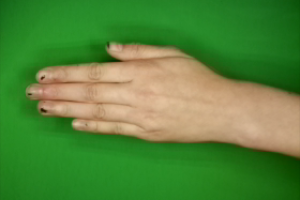

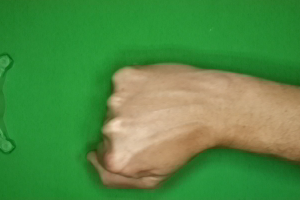

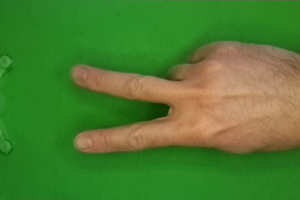

In [598]:
paper= Image.open('./train/paper/2IOsxsG8AaxntdJM.png')
paper.show()
rock= Image.open('./train/rock/2DdERUV7Te8ivywq.png')
rock.show()
scissors= Image.open('./train/scissors/2DEYFsJ27UgVqv3W.png')
scissors.show()


In [599]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="training",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="validation",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_size = len(temp_ds)

val_size = temp_size // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Found 2188 files belonging to 3 classes.
Using 1532 files for training.
Found 2188 files belonging to 3 classes.
Using 656 files for validation.


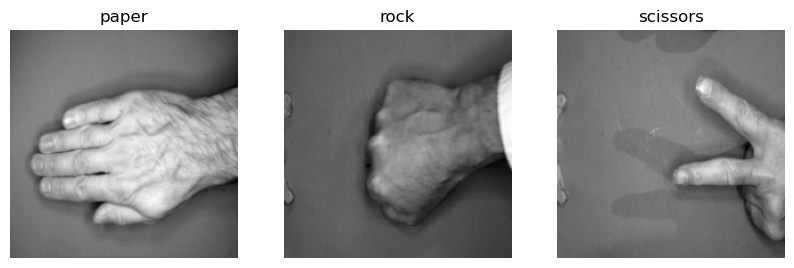

In [600]:
class_names = train_ds.class_names
# Display one image per class
shown_classes = set()
plt.figure(figsize=(10, 4))
for images, labels in train_ds.unbatch():
    label = labels.numpy()
    if label not in shown_classes:
        plt.subplot(1, len(class_names), len(shown_classes) + 1)
        plt.imshow(images.numpy().squeeze(), cmap="gray")  
        plt.title(class_names[label])
        plt.axis("off")
        shown_classes.add(label)
    if len(shown_classes) == len(class_names):
        break
plt.show()

In [601]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1)
])

In [602]:

if os.path.exists("model_1.h5"):
    model_1 = keras.models.load_model("model_1.h5")
    history_1 = pd.read_csv('./training_1.log',sep=',',engine='python')
else:
    model_1 = keras.Sequential(
        [
        
        layers.Rescaling(1./255),
        layers.Resizing(96, 96),        
       layers.Conv2D(16, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(96, 96, 1)),
       layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu",kernel_initializer='he_normal'),
        layers.Dense(3,activation='softmax')
    
        ]
    )
    csv_logger_1 = CSVLogger('training_1.log', separator=',', append=False)
    model_1.summary()
    model_1.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    history_1=model_1.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[csv_logger_1])
    history_1=history_1.history

/home/loren/miniconda3/envs/StatML/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_67"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_48 (Rescaling)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_16 (Resizing)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_112 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_112               │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_48 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.3812 - loss: 2.0108 - val_accuracy: 0.4250 - val_loss: 1.5421
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5751 - loss: 1.0111 - val_accuracy: 0.7406 - val_loss: 0.6678
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8244 - loss: 0.5294 - val_accuracy: 0.8438 - val_loss: 0.4573
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9054 - loss: 0.3518 - val_accuracy: 0.9031 - val_loss: 0.3372
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9112 - loss: 0.2943 - val_accuracy: 0.8813 - val_loss: 0.3669
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9380 - loss: 0.2315 - val_accuracy: 0.9094 - val_loss: 0.3023
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9413 - loss: 0.2064 - val_accuracy: 0.8875 - val_loss: 0.3419
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9289 - loss: 0.2035 - val_accuracy: 0.9062 - v

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


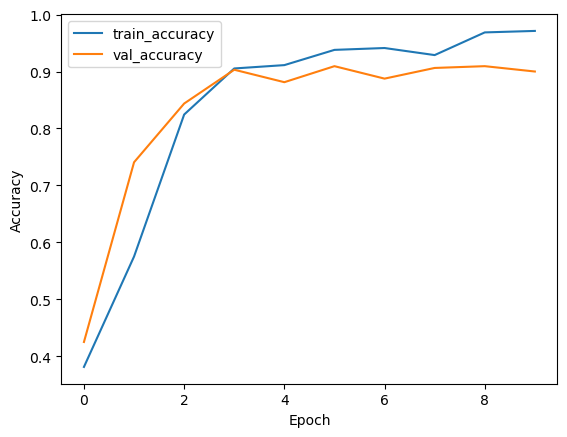

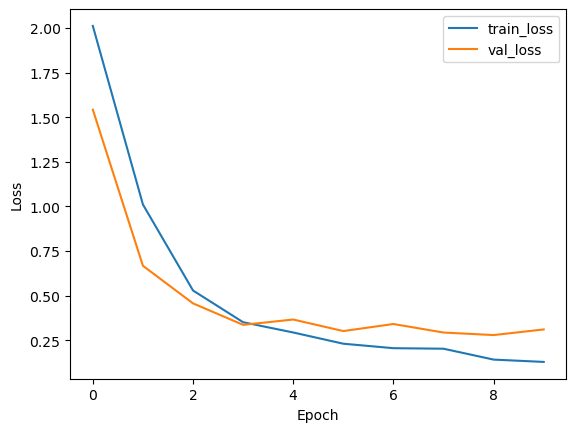

In [603]:
print(history_1.keys())
plt.plot(history_1["accuracy"], label="train_accuracy")
plt.plot(history_1["val_accuracy"], label="val_accuracy")
#plt.ylim(0.8, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(history_1["loss"], label="train_loss")
plt.plot(history_1["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
Predicted label: scissors
Actual label: scissors


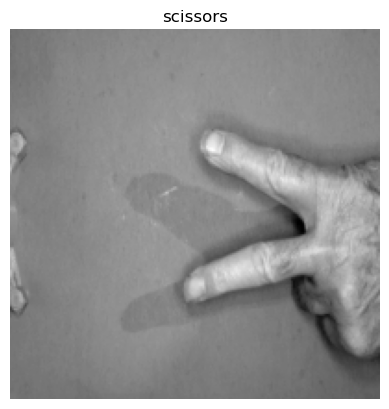

In [604]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_1.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

In [605]:
model_1.evaluate(test_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8750 - loss: 0.3499


[0.3499429225921631, 0.875]

In [606]:

if os.path.exists("model_2.h5"):
    model_2 = keras.models.load_model("model_2.h5")
    history_2 = pd.read_csv('./training_2.log',sep=',',engine='python')
else:
    model_2 = keras.Sequential(
        [
            data_augmentation,
        layers.Rescaling(1./255),
       layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(128, 128, 1)),
       layers.MaxPooling2D((2, 2)),
       layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
       layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu",kernel_initializer='he_normal'),
        layers.Dense(64, activation="relu",kernel_initializer='he_normal'),

        layers.Dense(3,activation='softmax')

        ]
    )
    csv_logger_2 = CSVLogger('training_2.log', separator=',', append=False)
    model_2.summary()

    model_2.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_2=model_2.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[csv_logger_2])
    history_2=history_2.history

Model: "sequential_68"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_66 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_49 (Rescaling)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_113 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_113               │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_114 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_114               │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_49 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.4393 - loss: 3.2335 - val_accuracy: 0.5938 - val_loss: 0.9151
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6638 - loss: 0.8260 - val_accuracy: 0.7063 - val_loss: 0.6872
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7108 - loss: 0.7069 - val_accuracy: 0.8844 - val_loss: 0.4073
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7552 - loss: 0.6042 - val_accuracy: 0.8469 - val_loss: 0.4638
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8101 - loss: 0.4925 - val_accuracy: 0.9125 - val_loss: 0.3027
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8349 - loss: 0.4503 - val_accuracy: 0.8938 - val_loss: 0.3344
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8342 - loss: 0.4332 - val_accuracy: 0.7625 - val_loss: 0.4586
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ -1s -16904us/step - accuracy: 0.8649 - loss: 0.3669 - val_accuracy: 0.943

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


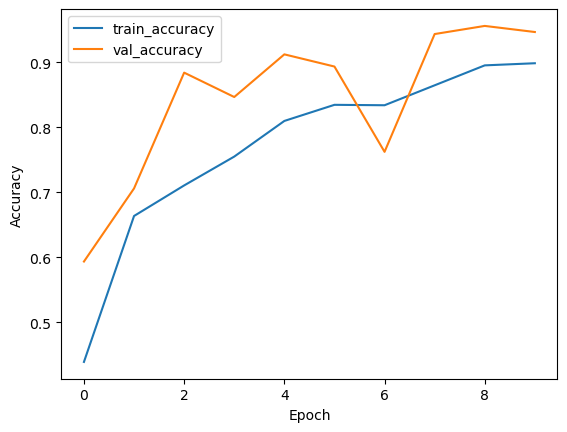

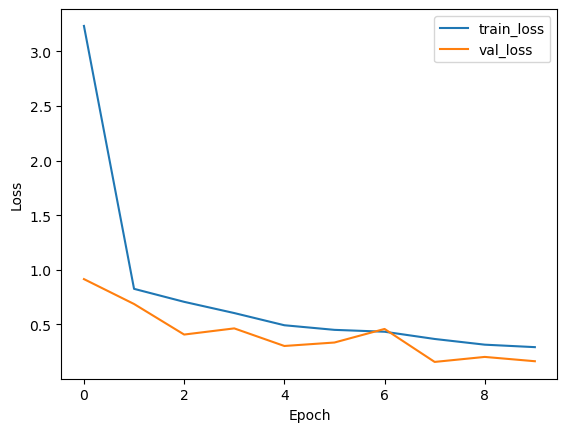

In [607]:
print(history_2.keys())
plt.plot(history_2["accuracy"], label="train_accuracy")
plt.plot(history_2["val_accuracy"], label="val_accuracy")
#plt.ylim(0.9, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(history_2["loss"], label="train_loss")
plt.plot(history_2["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [608]:
model_2.evaluate(test_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9554 - loss: 0.1513


[0.1513233333826065, 0.9553571343421936]

In [609]:
if os.path.exists("model_3.h5"):
    model_3 = keras.models.load_model("model_3.h5")
    history_3 = pd.read_csv('./training_3.log',sep=',',engine='python')
else:
    model_3 = keras.Sequential([

        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(200, 200, 1)),
        layers.MaxPooling2D((2, 2)), 

        layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(512, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu",name='dense_1',kernel_initializer='he_normal'),
        layers.Dropout(0.2),
        layers.Dense(64,activation='relu',kernel_initializer='he_normal'),
        layers.Dropout(0.2),
        layers.Dense(3, activation='softmax')
    ])
    csv_logger_3 = CSVLogger('training_3.log', separator=',', append=False)

    model_3.summary()
    model_3.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        #optimizer=keras.optimizers.Adadelta(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
        
    )
    history_3=model_3.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[csv_logger_3])
    history_3=history_3.history

Model: "sequential_69"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_66 (Sequential)      │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_50 (Rescaling)        │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_115 (Conv2D)             │ (None, 198, 198, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_115               │ (None, 99, 99, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_116 (Conv2D)             │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_116               │ (None, 48, 48, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_117 (Conv2D)             │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_117               │ (None, 23, 23, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_118 (Conv2D)             │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_118               │ (None, 10, 10, 256)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_119 (Conv2D)             │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_119               │ (None, 4, 4, 512)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_50 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,155 (10.01 MB)

 Trainable params: 2,625,155 (10.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.3662 - loss: 1.2063 - val_accuracy: 0.6844 - val_loss: 0.9710
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5594 - loss: 0.8964 - val_accuracy: 0.6687 - val_loss: 0.7417
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6338 - loss: 0.7252 - val_accuracy: 0.6719 - val_loss: 0.6582
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7037 - loss: 0.6397 - val_accuracy: 0.7906 - val_loss: 0.4737
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8016 - loss: 0.4785 - val_accuracy: 0.9500 - val_loss: 0.2307
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8864 - loss: 0.3503 - val_accuracy: 0.9688 - val_loss: 0.0938
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8897 - loss: 0.2984 - val_accuracy: 0.9406 - val_loss: 0.2119
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9419 - loss: 0.1935 - val_accuracy: 0.9187 - v

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


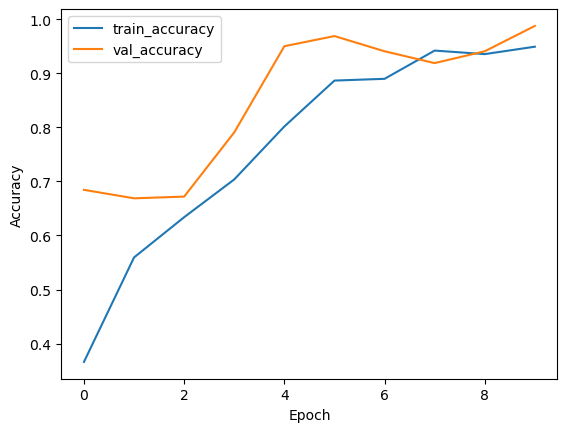

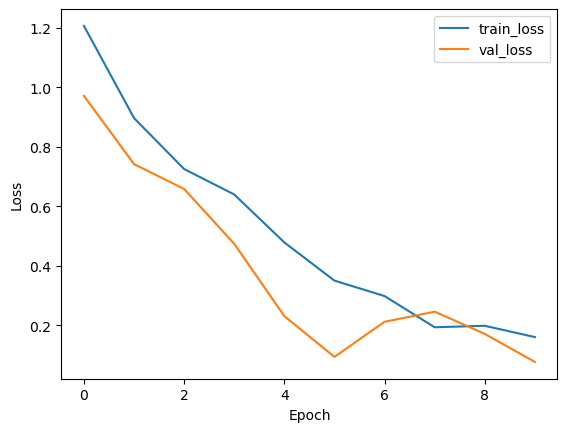

In [610]:
print(history_3.keys())
plt.plot(history_3["accuracy"], label="train_accuracy")
plt.plot(history_3["val_accuracy"], label="val_accuracy")
#plt.ylim(0.9, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(history_3["loss"], label="train_loss")
plt.plot(history_3["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Predicted label: rock
Actual label: rock


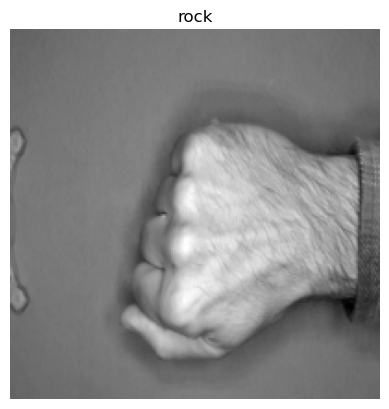

In [611]:

for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_3.predict(image[None, ...])
    

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()
    

In [612]:
y_test=[]
img_test=[]
y_pred_1=[]
y_pred_2=[]
y_pred_3=[]
for images, labels in test_ds.unbatch():
    y_test.append(labels.numpy())
    img_test.append(images.numpy())
    y_pred_1.append(np.argmax(model_1.predict(images[None, ...])[0]))
    y_pred_2.append(np.argmax(model_2.predict(images[None, ...])[0]))
    y_pred_3.append(np.argmax(model_3.predict(images[None, ...])[0]))

y_test = np.array(y_test)
img_test = np.array(img_test)
y_pred_1 = np.array(y_pred_1)
y_pred_2 = np.array(y_pred_2)
y_pred_3 = np.array(y_pred_3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

In [613]:
result_1=confusion_matrix(y_test, y_pred_1,labels=[0,1,2])

In [614]:
incorrect_indices_1 = np.where(y_pred_1 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_1)} out of {len(y_test)}")

Incorrectly classified samples: 45 out of 336


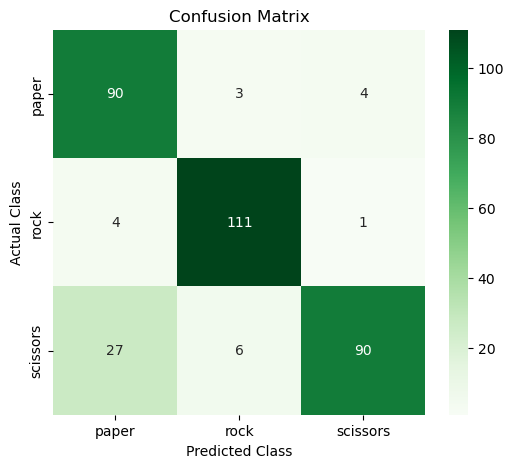

In [615]:
p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_1, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result_1,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_1, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


In [616]:
result_2=confusion_matrix(y_test, y_pred_2)

In [617]:
incorrect_indices_2 = np.where(y_pred_2 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_2)} out of {len(y_test)}")

Incorrectly classified samples: 17 out of 336


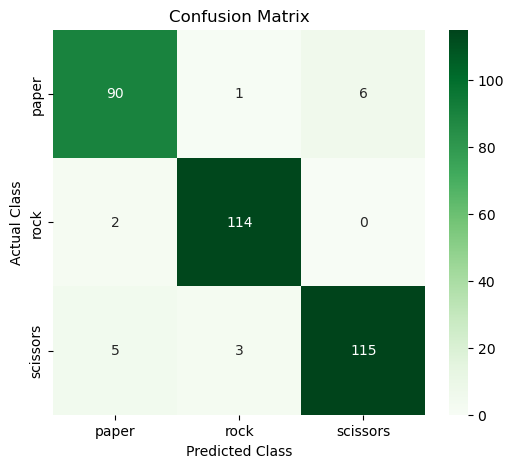

In [618]:
p=[('Predicted', x)  for x in class_names]
b=[('Real', x)  for x in class_names]
df = pd.DataFrame(result_2, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model2_cf=np.array(pd.DataFrame(result_2,columns=class_names,index=class_names))

plt.figure(figsize=(6,5))
sns.heatmap(result_2, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()

In [619]:

result_3=confusion_matrix(y_test, y_pred_3)

In [620]:
incorrect_indices_3 = np.where(y_pred_3 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_3)} out of {len(y_test)}")


Incorrectly classified samples: 6 out of 336


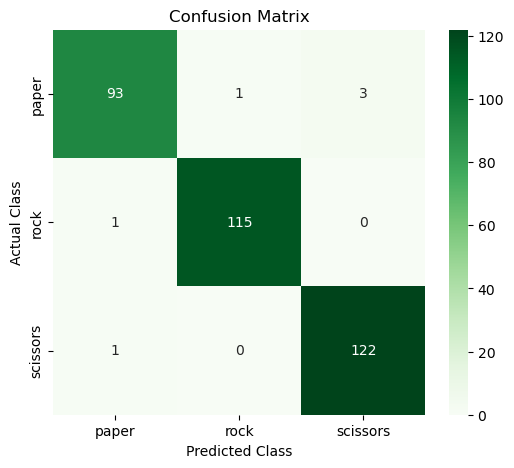

In [621]:
p=[('Predicted', x)  for x in class_names]
b=[('Real', x)  for x in class_names]
df = pd.DataFrame(result_3, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model3_cf=np.array(pd.DataFrame(result_3,columns=class_names,index=class_names))

plt.figure(figsize=(6,5))
sns.heatmap(result_3, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()

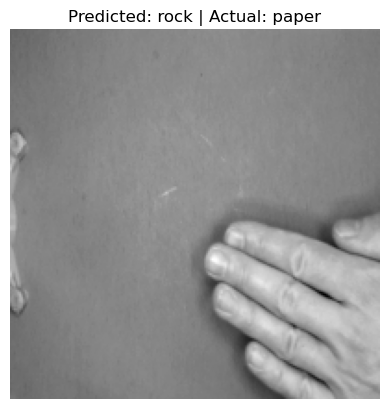

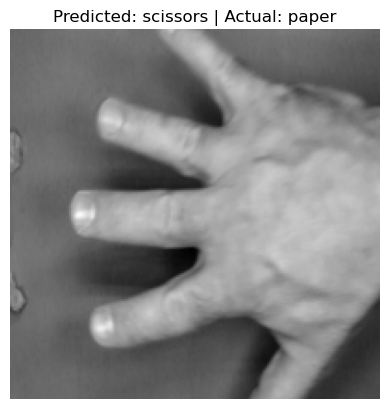

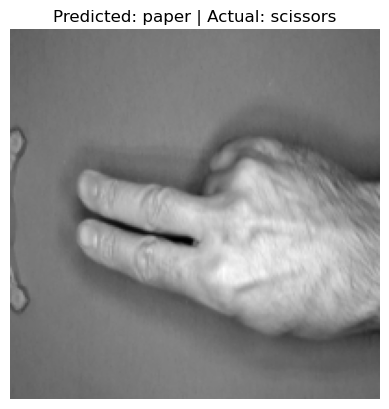

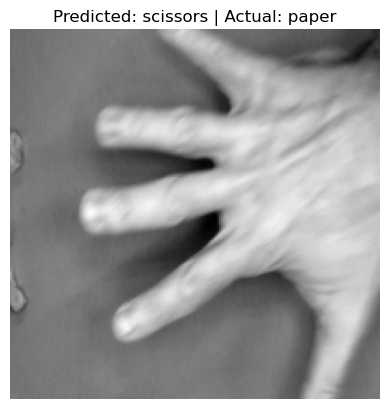

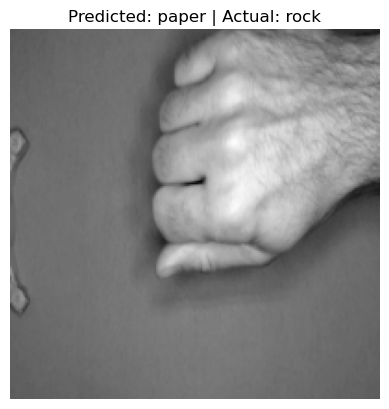

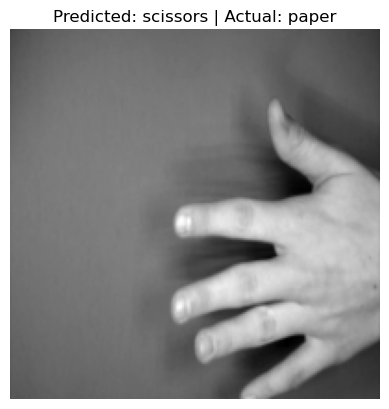

In [622]:
for idx in incorrect_indices_3:
    img=img_test[idx].squeeze()
    plt.imshow(img, cmap="gray")
    plt.title(f'Predicted: {class_names[y_pred_3[idx]]} | Actual: {class_names[y_test[idx]]}')
    plt.axis("off")
    plt.show()

In [623]:
m1_true_pos=np.diag(model1_cf)
m1_false_pos=np.sum(model1_cf, axis=0)-m1_true_pos
m1_false_neg=np.sum(model1_cf, axis=1)-m1_true_pos
m1_true_neg=np.sum(model1_cf)-m1_true_pos-m1_false_pos-m1_false_neg

m1_precision =m1_true_pos / (m1_true_pos + m1_false_pos)
m1_recall =m1_true_pos / (m1_true_pos + m1_false_neg)
m1_accuracy = np.sum(m1_true_pos) / np.sum(model1_cf)
m1_f1_score = 2 * (m1_precision * m1_recall) / (m1_precision + m1_recall)




In [624]:
print(f'------------------------model 1 performance metrics------------------------')
print(f'precision = {np.mean(m1_precision)}')
print(f'recall = {np.mean(m1_recall)}')
print(f'accuracy = {m1_accuracy}')
print(f'f1_score = {np.mean(m1_f1_score)}')


------------------------model 1 performance metrics------------------------
precision = 0.8720566913150645
recall = 0.8721463067812335
accuracy = 0.8660714285714286
f1_score = 0.8640180376302286


In [625]:
m2_true_pos=np.diag(model2_cf)
m2_false_pos=np.sum(model2_cf, axis=0)-m2_true_pos
m2_false_neg=np.sum(model2_cf, axis=1)-m2_true_pos
m2_true_neg=np.sum(model2_cf)-m2_true_pos-m2_false_pos-m2_false_neg


m2_precision =m2_true_pos / (m2_true_pos + m2_false_pos)
m2_recall =m2_true_pos / (m2_true_pos + m2_false_neg)
m2_accuracy = np.sum(m2_true_pos) / np.sum(model2_cf)
m2_f1_score = 2 * (m2_precision * m2_recall) / (m2_precision + m2_recall)




In [626]:
print(f'------------------------model 2 performance metrics------------------------')
print(f'precision = {np.mean(m2_precision)}')
print(f'recall = {np.mean(m2_recall)}')
print(f'accuracy = {m2_accuracy}')
print(f'f1_score = {np.mean(m2_f1_score)}')


------------------------model 2 performance metrics------------------------
precision = 0.9481166565340473
recall = 0.948517673943181
accuracy = 0.9494047619047619
f1_score = 0.9482723255750126


In [627]:
m3_true_pos=np.diag(model3_cf)
m3_false_pos=np.sum(model3_cf, axis=0)-m3_true_pos
m3_false_neg=np.sum(model3_cf, axis=1)-m3_true_pos
m3_true_neg=np.sum(model3_cf)-m3_true_pos-m3_false_pos-m3_false_neg


m3_precision =m3_true_pos / (m3_true_pos + m3_false_pos)
m3_recall =m3_true_pos / (m3_true_pos + m3_false_neg)
m3_accuracy = np.sum(m3_true_pos) / np.sum(model3_cf)
m3_f1_score = 2 * (m3_precision * m3_recall) / (m3_precision + m3_recall)




In [628]:
print(f'------------------------model 3 performance metrics------------------------')
print(f'precision = {np.mean(m3_precision)}')
print(f'recall = {np.mean(m3_recall)}')
print(f'accuracy = {m3_accuracy}')
print(f'f1_score = {np.mean(m3_f1_score)}')

------------------------model 3 performance metrics------------------------
precision = 0.9821088929219601
recall = 0.9806707052139841
accuracy = 0.9821428571428571
f1_score = 0.9813334260289212


In [629]:

if not os.path.exists("model_1.h5"):
        model_1.save("model_1.h5")
if not os.path.exists("model_2.h5"):
        model_2.save("model_2.h5")
if not os.path.exists("model_3.h5"):
        model_3.save("model_3.h5")